In [1]:
import lightning as L
from pytorch_lightning.loggers import CSVLogger
from torchvision import transforms
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint


### Improving over v9

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data"
DATA_PATH

PosixPath('/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/data')

In [3]:
from src.model_training_pipeline import TripletSiameseModel  
from src.datamodule import TripletDataModule  
from src.random_seed_utils import seed_everything

In [4]:
seed_everything()

### Changes

| # | Change                                                               | Expected Effect                                                                                                                                                                    |
| - | -------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | **Replaced top-k hard triplet mining with semi-hard triplet mining** | Selects triplets where `pos_dist < neg_dist < pos_dist + margin`, avoiding extremely hard or trivial samples and leading to more stable gradients and better embedding separation. |


In [5]:
train_transforms = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.Grayscale(num_output_channels=3),

        transforms.RandomRotation(5),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.02, 0.02),  
            scale=(0.95, 1.05),       
            shear=2                
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])


val_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])



In [6]:
dm = TripletDataModule(
    data_dir=DATA_PATH,
    batch_size=64,
    num_workers=4,
    image_size=128,
    pin_memory=False,
    samples_per_epoch=10000,
    train_transformations=train_transforms,
    val_transformations=val_transforms,
    test_transformations=test_transforms
)

# Setup datasets (fit stage)
dm.setup(stage="fit")

In [7]:
print(
    "Train:", len(dm.train_dataset),
    "Val:", len(dm.val_dataset),
    "Test:", len(getattr(dm, "test_dataset", []))
)

Train: 10000 Val: 10000 Test: 0


In [8]:
len(dm.train_dataloader()), len(dm.val_dataloader())

(156, 40)

In [9]:
train_loader = dm.train_dataloader()
val_loader   = dm.val_dataloader()

print("Train batches per epoch:", len(train_loader))
print("Val batches per epoch:", len(val_loader))

Train batches per epoch: 156
Val batches per epoch: 40


In [10]:
# from src.dataloader_utils import sanity_check_triplet_loader


# sanity_check_triplet_loader(loader=dm.train_dataloader(),split_name="train")
# sanity_check_triplet_loader(loader=dm.val_dataloader(),split_name="val")

In [11]:
model = TripletSiameseModel(
    embedding_dim=256,
    lr=1e-4,
    margin=0.3
)

In [12]:
logger = CSVLogger("train_logs", name="siamese_signature")

In [13]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",      # metric to monitor
    patience=5,              # stop if no improvement after 5 epochs
    mode="min",              # we want to minimize val_loss
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",      # metric to monitor
    dirpath="checkpoints",   # folder to save checkpoints
    filename="siamese-{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,            # save only the best model
    mode="min",
    verbose=True
)

In [14]:
trainer = L.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices=1,
    logger=logger,
    log_every_n_steps=1,
    callbacks=[early_stop_callback, checkpoint_callback]
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [15]:
trainer.fit(model, datamodule=dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/post_train_nb/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone             │ Sequential │ 11.2 M │ train │     0 │
│ 1 │ embedding_head       │ Linear     │  131 K │ train │     0 │
│ 2 │ train_loss_metric    │ MeanMetric │      0 │ train │     0 │
│ 3 │ val_loss_metric      │ MeanMetric │      0 │ train │     0 │
│ 4 │ val_violation_metric │ MeanMetric │      0 │ train │     0 │
└───┴──────────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 10.6 M                                                                                           
Non-trainable params: 683 K                                                                                        
Total params: 11.3 M                                                                                               
Total estimated model params size (MB): 45                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/.venv/lib/python3.11/site-packages/lightning/pyto
rch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) 
and treespec.is_leaf()` instead.

...

Epoch 18, global step 2964: 'val_loss' was not in top 1


Epoch 19, global step 3120: 'val_loss' was not in top 1


Epoch 20, global step 3276: 'val_loss' was not in top 1


Epoch 21, global step 3432: 'val_loss' was not in top 1


Monitored metric val_loss did not improve in the last 5 records. Best score: 0.000. Signaling Trainer to stop.
Epoch 22, global step 3588: 'val_loss' was not in top 1


In [16]:
checkpoint_path = "train_logs/siamese_signature/version_10/checkpoints/epoch=22-step=3588.ckpt"
model = TripletSiameseModel.load_from_checkpoint(embedding_dim=256,checkpoint_path=checkpoint_path)
model.eval()

TripletSiameseModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

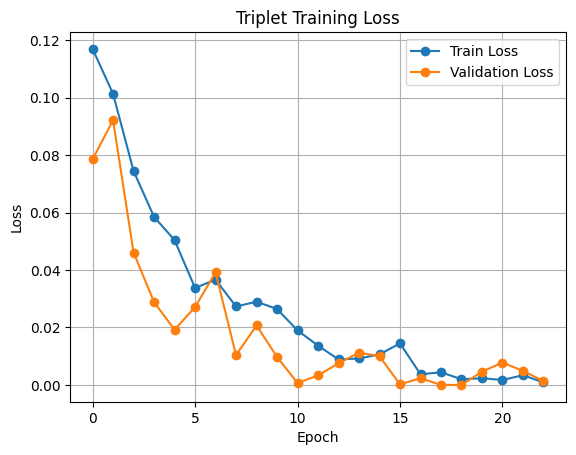

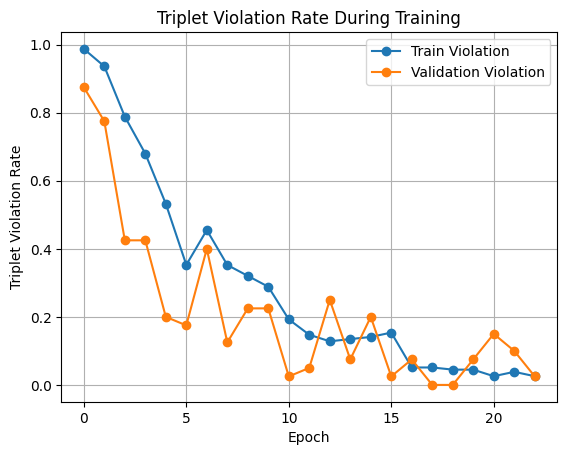

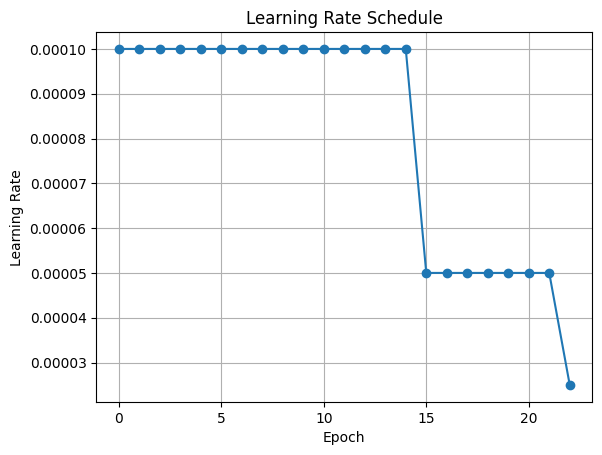

In [17]:
from src.train_metrics_utils import plot_triplet_training_metrics


metrics = plot_triplet_training_metrics(csv_path="train_logs/siamese_signature/version_10/metrics.csv")


In [18]:
dm.setup(stage="test") 

In [19]:
test_loader = dm.test_dataloader()
len(dm.test_dataset)

10000

In [20]:
len(test_loader)

157

In [21]:
trainer.test(model, datamodule=dm)



/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

Test samples: 10000

Pos distance mean: 0.2729, Neg distance mean: 1.2054

[{}]

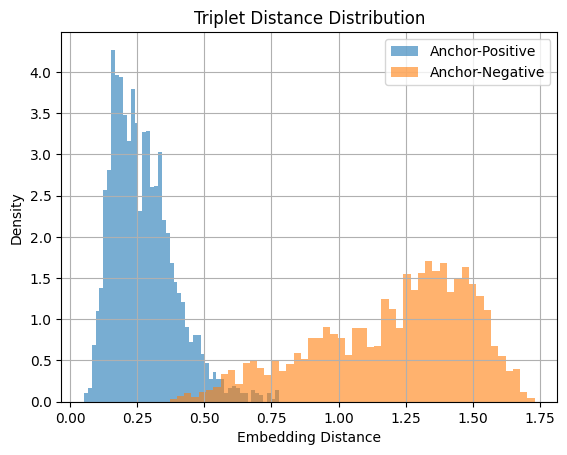

In [22]:
from src.inference_utils import plot_triplet_distance_distributions


plot_triplet_distance_distributions(
    model.test_pos_distances,
    model.test_neg_distances
)

In [23]:
from src.inference_utils import find_best_threshold


t, acc = find_best_threshold(
    model.test_pos_distances,
    model.test_neg_distances
)

print("Best threshold:", t)
print("Best accuracy:", acc)

Best threshold: 0.5655121
Best accuracy: 0.9792
